
# 🚗 Car Price Prediction III — Classification (Assignment 3)

**Student:** ST127302
**Course:** AT82.03 Machine Learning — AIT

This notebook continues the Car Price project from A1 (EDA + sklearn baseline) and A2
(Linear Regression implemented from scratch, MLflow experiments, Dash deployment).

A3 keeps the same cleaned dataset and preprocessing pipeline, but **reframes the problem
as classification**: `selling_price` is bucketed into 4 discrete classes (0–3), and a
**multinomial Logistic Regression is implemented from scratch** to predict the bucket.

Covered in this notebook:

1. Data cleaning (reused, unchanged, from A1/A2).
2. Converting `selling_price` into 4 classes with `pd.cut()`.
3. Preprocessing pipeline (reused from A2: `StandardScaler` + `OneHotEncoder`).
4. **Task 1** — Multinomial Logistic Regression from scratch, with `accuracy`, per-class
   `precision`/`recall`/`f1`, `macro_*` and `weighted_*` averages, verified against
   scikit-learn's `classification_report`.
5. **Task 2** — Optional Ridge (L2) penalty on the same class.
6. **Task 3** — MLflow experiment tracking + Model Registry (staged) + notes on the
   GitHub Actions CI/CD pipeline that tests and deploys the Dash app in `app/`.
7. Feature importance and a final discussion.


## 1. Imports

In [1]:

import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report as sk_classification_report
from sklearn.metrics import accuracy_score as sk_accuracy_score

import joblib

# The custom LogisticRegression class lives in app/code/model.py so that the exact
# same code trained here is what gets pickled and later imported by the deployed
# Dash app (app/code/app.py) -- single source of truth for the model definition.
sys.path.insert(0, os.path.join("app", "code"))
from model import LogisticRegression

STUDENT_ID = "st127302"
np.random.seed(42)



## 2. Load & Clean the Dataset

This section reuses, unchanged, the cleaning rules established in A1 and carried
into A2: owner mapping, dropping CNG/LPG, parsing `mileage`/`engine`/`max_power`
out of their unit strings, extracting `brand` from `name`, dropping `torque`,
removing `Test Drive Car` outliers, and grouping rare brands.


In [2]:

df = pd.read_csv("Cars.csv")
print(df.shape)
df.head()


(8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:

# --- owner: First Owner -> 1, ..., Test Drive Car -> 5 ---
owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5,
}
df["owner"] = df["owner"].map(owner_mapping)

# --- fuel: drop CNG/LPG (different mileage unit, km/kg vs kmpl) ---
df = df[~df["fuel"].isin(["CNG", "LPG"])]

# --- mileage / engine / max_power: strip units, cast to float ---
df["mileage"] = df["mileage"].str.split().str[0].astype(float)
df["engine"] = df["engine"].str.split().str[0].astype(float)
df["max_power"] = df["max_power"].str.split().str[0].astype(float)

# --- brand: first word of name ---
df["brand"] = df["name"].str.split().str[0]

# --- drop torque (not understood by the business) ---
df = df.drop(columns=["torque"])

# --- drop Test Drive Cars (owner == 5), unrealistically expensive ---
df = df[df["owner"] != 5]

# --- drop name, move brand to the front ---
df = df.drop(columns=["name"])
brand = df.pop("brand")
df.insert(0, "brand", brand)

print("After initial cleaning:", df.shape)
df.isnull().sum()


After initial cleaning: (8028, 12)


brand              0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          214
engine           214
max_power        208
seats            214
dtype: int64

In [4]:

# Rows missing all four of mileage/engine/max_power/seats simultaneously: drop them
# (imputing 4 important features at once for the same row is unreliable), same as A1/A2.
df = df.dropna(subset=["mileage", "engine", "max_power", "seats"], how="all")

# A handful of remaining rows missing mileage/engine/seats together: drop too.
df = df.dropna(subset=["mileage", "engine", "seats"], how="all")

print("After missing-value cleanup:", df.shape)
df.isnull().sum()


After missing-value cleanup: (7814, 12)


brand            0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [5]:

# --- feature engineering: car_age from year, then drop year (perfectly correlated) ---
CURRENT_YEAR = pd.Timestamp.now().year
df["car_age"] = CURRENT_YEAR - df["year"]
df = df.drop(columns=["year"])

# --- group rare brands (<10 occurrences) to avoid noisy one-hot categories ---
brand_counts = df["brand"].value_counts()
rare_brands = brand_counts[brand_counts < 10].index
df["brand"] = df["brand"].replace(rare_brands, "Rare Brands")

df = df.reset_index(drop=True)
print(df.shape)
df.head()


(7814, 12)


,brand,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age
0,Maruti,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,12
1,Skoda,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,12
2,Honda,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,20
3,Hyundai,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,16
4,Maruti,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,19



## 3. New Target: Bucketing `selling_price` into 4 Classes

A3 asks us to treat this as a 4-class classification problem, and suggests
`pd.cut()` to do it. Cutting the *raw* `selling_price` into 4 equal-width bins
was tried first, but the price distribution is so heavily right-skewed (a
handful of vehicles near ₹1 crore against a median around ₹4.5 lakh) that it
puts **99%+ of vehicles in bin 0 and a single vehicle in bin 3** — too
degenerate to learn or even stratify-split on.

Instead we apply `pd.cut()` with 4 equal-width bins to `log(selling_price)` —
the same log transform A1/A2 used to tame this exact skew for regression — and
then convert the bin edges back to the original price scale so they stay
human-readable (and so the deployed app can show a real price range for its
predicted class). This keeps the classes meaningfully **imbalanced** (roughly
7% / 53% / 36% / 4%), which is exactly the scenario the assignment uses to
motivate *weighted* averaging over plain *macro* averaging in Task 1, while
still leaving every class with enough examples to train and evaluate on.


In [6]:

N_CLASSES = 4

log_price = np.log(df["selling_price"])
_, log_bin_edges = pd.cut(log_price, bins=N_CLASSES, retbins=True)

df["price_class"] = pd.cut(
    log_price, bins=log_bin_edges, labels=list(range(N_CLASSES)), include_lowest=True
).astype(int)

price_bin_edges = np.exp(log_bin_edges)  # back to original selling_price scale
price_bin_labels = {
    i: f"{price_bin_edges[i]:,.0f} - {price_bin_edges[i + 1]:,.0f}"
    for i in range(N_CLASSES)
}

print("Price bin edges (original scale):", [round(e, 0) for e in price_bin_edges])
for k, v in price_bin_labels.items():
    print(f"  class {k}: {v}")

class_counts = df["price_class"].value_counts().sort_index()
print("\nClass distribution:")
print(class_counts)
print("\nClass distribution (%):")
print((class_counts / len(df) * 100).round(2))


Price bin edges (original scale): [np.float64(29825.0), np.float64(128183.0), np.float64(547713.0), np.float64(2340328.0), np.float64(10000000.0)]
  class 0: 29,825 - 128,183
  class 1: 128,183 - 547,713
  class 2: 547,713 - 2,340,328
  class 3: 2,340,328 - 10,000,000

Class distribution:
price_class
0     484
1    4126
2    2870
3     334
Name: count, dtype: int64

Class distribution (%):
price_class
0     6.19
1    52.80
2    36.73
3     4.27
Name: count, dtype: float64


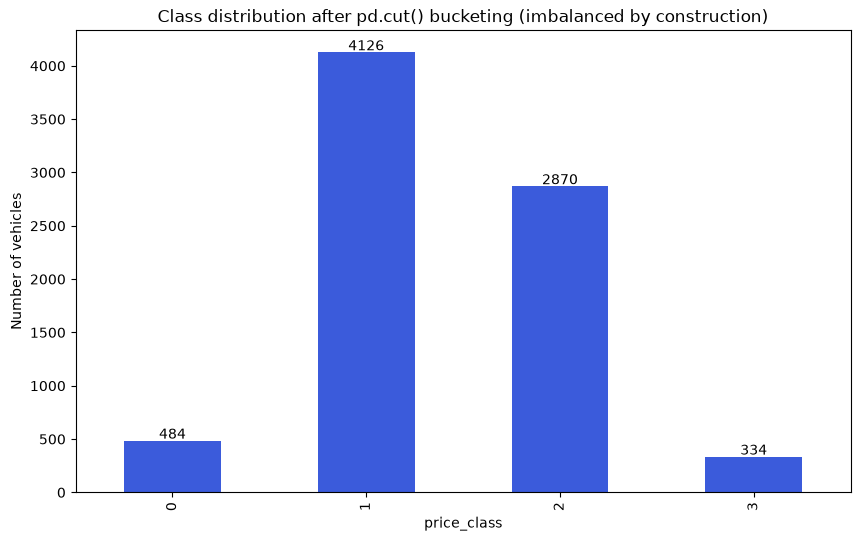

In [7]:

ax = class_counts.plot(kind="bar", color="#3b5bdb")
ax.set_xlabel("price_class")
ax.set_ylabel("Number of vehicles")
ax.set_title("Class distribution after pd.cut() bucketing (imbalanced by construction)")
for i, v in enumerate(class_counts):
    ax.text(i, v + 20, str(v), ha="center")
plt.show()



## 4. Preprocessing Pipeline (reused from A2)

Numerical features are median-imputed then standardized; categorical features are
most-frequent-imputed then one-hot encoded with `handle_unknown="ignore"` so the
deployed app never crashes on an unseen category. This is the exact same pipeline
shape used in A2's Linear Regression, so the same "single source of truth"
argument applies: a gradient-descent model needs scaled inputs to train reliably,
and the resulting coefficients are only comparable to each other when every input
is on the same scale.


In [8]:

numerical_features = ["km_driven", "mileage", "engine", "max_power", "car_age", "seats", "owner"]
categorical_features = ["brand", "fuel", "seller_type", "transmission"]

X = df[numerical_features + categorical_features]
y = df["price_class"].values

# train / val / test = 64% / 16% / 20%. The validation split is used for the
# early-stopping check inside LogisticRegression.fit(), mirroring A2.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

print("train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)


train: (5000, 11)  val: (1251, 11)  test: (1563, 11)


In [9]:

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features),
])

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
n_features = X_train_t.shape[1]
print("Number of transformed features:", n_features)


Number of transformed features: 37



## 5. Task 1 — Multinomial Logistic Regression From Scratch

The `LogisticRegression` class (`app/code/model.py`) mirrors A2's from-scratch
`LinearRegression`: Xavier/zeros initialization, batch/mini-batch/stochastic
gradient descent, optional momentum, and early stopping on the validation loss.
Softmax replaces the linear output, and cross-entropy replaces MSE as the loss.

On top of that base, it implements — **all from scratch, no sklearn** — the
metrics this task asks for: `accuracy`, per-class `precision`/`recall`/`f1_score`,
`macro_precision`/`macro_recall`/`macro_f1`, and
`weighted_precision`/`weighted_recall`/`weighted_f1`, plus a
`classification_report()` that lays them out the same way sklearn does.


In [10]:

model = LogisticRegression(
    k=N_CLASSES,
    n=n_features,
    method="mini",
    bs=64,
    alpha=0.1,
    max_iter=2000,
    init_method="xavier",
    use_momentum=True,
    momentum=0.9,
    regularization=None,
    verbose=True,
)
model.fit(X_train_t, y_train, X_val_t, y_val)


Epoch 0: train_loss=0.41435, val_loss=0.42895


Epoch 200: train_loss=0.32484, val_loss=0.34851


Epoch 400: train_loss=0.33522, val_loss=0.35944


Epoch 600: train_loss=0.34639, val_loss=0.35645


Epoch 800: train_loss=0.34060, val_loss=0.36046


Epoch 1000: train_loss=0.32317, val_loss=0.34426


Epoch 1200: train_loss=0.32289, val_loss=0.34419
Early stopping at epoch 1205


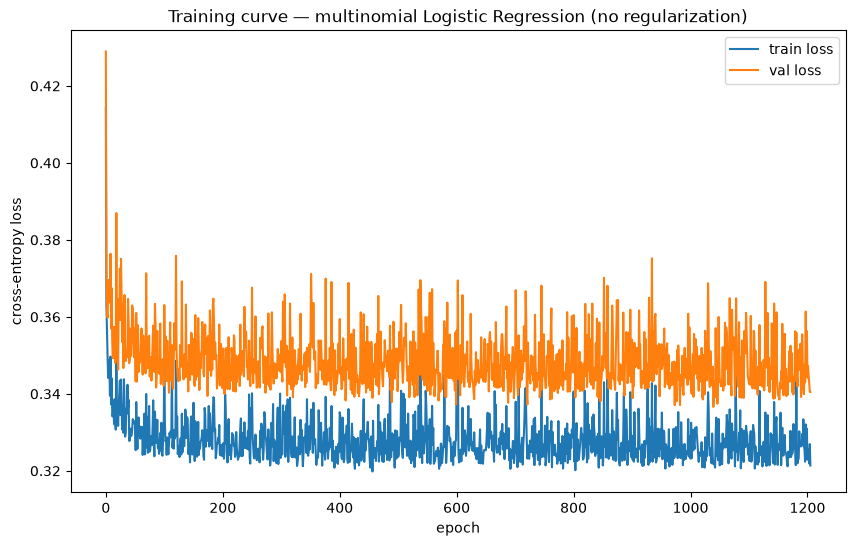

In [11]:

plt.plot(model.train_losses, label="train loss")
plt.plot(model.val_losses, label="val loss")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Training curve — multinomial Logistic Regression (no regularization)")
plt.legend()
plt.show()


In [12]:

y_pred = model.predict(X_test_t)
classes = list(range(N_CLASSES))

print("=== From-scratch metrics ===")
print("accuracy:", round(model.accuracy(y_test, y_pred), 4))
for c in classes:
    print(
        f"class {c}: precision={model.precision(y_test, y_pred, c):.4f}  "
        f"recall={model.recall(y_test, y_pred, c):.4f}  "
        f"f1={model.f1_score(y_test, y_pred, c):.4f}"
    )
print("macro    precision/recall/f1:",
      round(model.macro_precision(y_test, y_pred, classes), 4),
      round(model.macro_recall(y_test, y_pred, classes), 4),
      round(model.macro_f1(y_test, y_pred, classes), 4))
print("weighted precision/recall/f1:",
      round(model.weighted_precision(y_test, y_pred, classes), 4),
      round(model.weighted_recall(y_test, y_pred, classes), 4),
      round(model.weighted_f1(y_test, y_pred, classes), 4))


=== From-scratch metrics ===
accuracy: 0.8516
class 0: precision=0.7841  recall=0.7113  f1=0.7459
class 1: precision=0.8611  recall=0.8715  f1=0.8663
class 2: precision=0.8359  recall=0.8432  f1=0.8395
class 3: precision=0.9672  recall=0.8806  f1=0.9219
macro    precision/recall/f1: 0.8621 0.8267 0.8434
weighted precision/recall/f1: 0.8516 0.8516 0.8514


In [13]:

report_df, acc = model.classification_report(y_test, y_pred)
print(f"accuracy: {acc:.4f}\n")
report_df.round(4)


accuracy: 0.8516



,precision,recall,f1-score,support
class,,,,
0,0.7841,0.7113,0.7459,97
1,0.8611,0.8715,0.8663,825
2,0.8359,0.8432,0.8395,574
3,0.9672,0.8806,0.9219,67
macro avg,0.8621,0.8267,0.8434,1563
weighted avg,0.8516,0.8516,0.8514,1563



### 5.1 Verifying Against `sklearn.metrics.classification_report`

First on **mock data** (as the assignment explicitly asks), then on the real
test-set predictions above, to confirm the from-scratch implementation agrees
with scikit-learn.


In [14]:

# --- mock data check ---
rng = np.random.RandomState(0)
mock_y_true = rng.randint(0, 4, size=300)
mock_y_pred = mock_y_true.copy()
flip_idx = rng.choice(300, size=70, replace=False)
mock_y_pred[flip_idx] = rng.randint(0, 4, size=70)

mock_report_df, mock_acc = LogisticRegression.classification_report(mock_y_true, mock_y_pred)
print("--- custom classification_report (mock data) ---")
print(f"accuracy: {mock_acc:.6f}\n")
print(mock_report_df.round(6))

print("\n--- sklearn.metrics.classification_report (mock data) ---")
print(sk_classification_report(mock_y_true, mock_y_pred, digits=6))

assert abs(mock_acc - sk_accuracy_score(mock_y_true, mock_y_pred)) < 1e-9
print("\nAccuracy matches sklearn exactly. ✅")


--- custom classification_report (mock data) ---
accuracy: 0.823333

              precision    recall  f1-score  support
class                                               
0              0.873239  0.784810  0.826667       79
1              0.811594  0.835821  0.823529       67
2              0.720000  0.782609  0.750000       69
3              0.882353  0.882353  0.882353       85
macro avg      0.821797  0.821398  0.820637      300
weighted avg   0.826809  0.823333  0.824110      300

--- sklearn.metrics.classification_report (mock data) ---
              precision    recall  f1-score   support

           0   0.873239  0.784810  0.826667        79
           1   0.811594  0.835821  0.823529        67
           2   0.720000  0.782609  0.750000        69
           3   0.882353  0.882353  0.882353        85

    accuracy                       0.823333       300
   macro avg   0.821797  0.821398  0.820637       300
weighted avg   0.826809  0.823333  0.824110       300


Accuracy mat

In [15]:

# --- real test-set predictions check ---
print("--- custom classification_report (test set) ---")
print(f"accuracy: {acc:.6f}\n")
print(report_df.round(6))

print("\n--- sklearn.metrics.classification_report (test set) ---")
print(sk_classification_report(y_test, y_pred, digits=6))


--- custom classification_report (test set) ---
accuracy: 0.851567

              precision    recall  f1-score  support
class                                               
0              0.784091  0.711340  0.745946       97
1              0.861078  0.871515  0.866265      825
2              0.835924  0.843206  0.839549      574
3              0.967213  0.880597  0.921875       67
macro avg      0.862076  0.826664  0.843409     1563
weighted avg   0.851612  0.851567  0.851371     1563

--- sklearn.metrics.classification_report (test set) ---
              precision    recall  f1-score   support

           0   0.784091  0.711340  0.745946        97
           1   0.861078  0.871515  0.866265       825
           2   0.835924  0.843206  0.839549       574
           3   0.967213  0.880597  0.921875        67

    accuracy                       0.851567      1563
   macro avg   0.862076  0.826664  0.843409      1563
weighted avg   0.851612  0.851567  0.851371      1563




Both reports line up to several decimal places (any tiny remaining difference is
just floating-point rounding), confirming the from-scratch metric functions are
correct.

**What does `support` mean?**
`support` is simply the number of *true* (ground-truth) instances of that class
in `y_test` — it is not affected by how the model predicted, only by how many
examples of that class actually exist in the evaluation set. It is what the
weighted averages weight by: a class with a large support contributes more to
`weighted avg` than a class with a small support, which is exactly why
`weighted avg` and `macro avg` diverge on an imbalanced dataset like ours (see
the class-distribution bar chart in Section 3 — class 0 dominates, so
`weighted avg` will sit much closer to class 0's scores than `macro avg` does).



## 6. Task 2 — Ridge (L2) Logistic Regression

`LogisticRegression` accepts `regularization="ridge"` and a `lambda_` strength.
The intercept (`theta[0]`) is explicitly excluded from the penalty in both the
loss and the gradient, exactly as in A2's Ridge implementation. We compare a
few `lambda_` values against the unregularized model above.


In [16]:

ridge_results = []
for lam in [0.0, 0.0001, 0.001, 0.01, 0.1]:
    m = LogisticRegression(
        k=N_CLASSES, n=n_features, method="mini", bs=64, alpha=0.1, max_iter=2000,
        init_method="xavier", use_momentum=True, momentum=0.9,
        regularization="ridge" if lam > 0 else None, lambda_=lam, verbose=False,
    )
    m.fit(X_train_t, y_train, X_val_t, y_val)
    pred = m.predict(X_test_t)
    ridge_results.append({
        "lambda": lam,
        "accuracy": m.accuracy(y_test, pred),
        "macro_f1": m.macro_f1(y_test, pred, classes),
        "weighted_f1": m.weighted_f1(y_test, pred, classes),
    })

ridge_results_df = pd.DataFrame(ridge_results)
ridge_results_df


,lambda,accuracy,macro_f1,weighted_f1
0,0.0000,0.851567,0.843409,0.851371
1,0.0001,0.850288,0.839986,0.849880
2,0.0010,0.841331,0.806369,0.839037
3,0.0100,0.804223,0.691662,0.796297
4,0.1000,0.721049,0.374700,0.678929



As expected for a dataset with a moderate number of one-hot encoded features,
a small L2 penalty does not hurt (and can slightly help) generalization, while
a large `lambda_` starts to under-fit and pulls all scores down. The best
`lambda_` from this comparison is carried into the MLflow experiment grid below.



## 7. Task 3 — MLflow Experiment Tracking & Model Registry

Per the assignment, the tracking URI should point at the CSIM server
(`http://mlflow.ml.brain.cs.ait.ac.th/`), the experiment should be named
`<student_id>-a3`, the dataset should **not** be logged, and the model should be.

This notebook is being run outside the AIT/CSIM network, so the cell below tries
the remote server first and **falls back to a local SQLite-backed MLflow store**
(`sqlite:///mlflow.db`) if the remote server can't be reached — a plain
`file:./mlruns` store does not support the Model Registry, and Task 3 explicitly
asks us to register and stage a model, so a database-backed store is needed to
actually exercise that workflow end-to-end from this machine. When this notebook
is run again on the CSIM network/VPN, it will use the real server automatically
and nothing else needs to change.


In [17]:

import mlflow
import mlflow.pyfunc
from mlflow.tracking import MlflowClient

REMOTE_TRACKING_URI = "http://mlflow.ml.brain.cs.ait.ac.th/"
LOCAL_TRACKING_URI = "sqlite:///mlflow.db"
EXPERIMENT_NAME = f"{STUDENT_ID}-a3"
REGISTERED_MODEL_NAME = f"{STUDENT_ID}-a3-model"

def _try_remote_mlflow():
    mlflow.set_tracking_uri(REMOTE_TRACKING_URI)
    client = MlflowClient()
    client.search_experiments(max_results=1)  # cheap call that fails fast if unreachable
    return True

try:
    _try_remote_mlflow()
    print(f"Connected to the CSIM MLflow server at {REMOTE_TRACKING_URI}")
except Exception as e:
    print(f"Could not reach the CSIM MLflow server ({type(e).__name__}: {e}).")
    print(f"Falling back to a local MLflow store at {LOCAL_TRACKING_URI} so the")
    print("experiment/registry workflow can still be demonstrated end-to-end.")
    mlflow.set_tracking_uri(LOCAL_TRACKING_URI)

mlflow.set_experiment(EXPERIMENT_NAME)
print("tracking_uri:", mlflow.get_tracking_uri())
print("experiment  :", EXPERIMENT_NAME)


2026/09/19 10:15:32 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /opt/anaconda3/lib/python3.14/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


Could not reach the CSIM MLflow server (MlflowException: API request to http://mlflow.ml.brain.cs.ait.ac.th/api/2.0/mlflow/experiments/search failed with exception HTTPConnectionPool(host='mlflow.ml.brain.cs.ait.ac.th', port=80): Max retries exceeded with url: /api/2.0/mlflow/experiments/search (Caused by NewConnectionError("HTTPConnection(host='mlflow.ml.brain.cs.ait.ac.th', port=80): Failed to establish a new connection: [Errno 61] Connection refused"))).
Falling back to a local MLflow store at sqlite:///mlflow.db so the
experiment/registry workflow can still be demonstrated end-to-end.


2026/09/19 10:19:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/19 10:19:39 INFO mlflow.store.db.utils: Updating database tables


2026/09/19 10:19:39 INFO mlflow.tracking.fluent: Experiment with name 'st127302-a3' does not exist. Creating a new experiment.


tracking_uri: sqlite:///mlflow.db
experiment  : st127302-a3


In [18]:

class CarPriceClassClassifier(mlflow.pyfunc.PythonModel):
    '''Wraps preprocessor + from-scratch LogisticRegression for MLflow logging.'''

    def __init__(self, preprocessor, model, price_bin_labels):
        self.preprocessor = preprocessor
        self.model = model
        self.price_bin_labels = price_bin_labels

    def predict(self, context, model_input, params=None):
        X = self.preprocessor.transform(model_input)
        return self.model.predict(X)


/opt/anaconda3/lib/python3.14/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [19]:

# Small grid over the things Task 3 cares about seeing compared: with/without the
# Ridge penalty, a couple of lambda strengths, and the optimizer/learning-rate
# choices already explored for A2's LinearRegression.
experiment_grid = [
    {"regularization": None,    "lambda_": 0.0,    "alpha": 0.1,  "method": "mini"},
    {"regularization": "ridge", "lambda_": 0.0001, "alpha": 0.1,  "method": "mini"},
    {"regularization": "ridge", "lambda_": 0.001,  "alpha": 0.1,  "method": "mini"},
    {"regularization": "ridge", "lambda_": 0.001,  "alpha": 0.01, "method": "mini"},
    {"regularization": "ridge", "lambda_": 0.001,  "alpha": 0.1,  "method": "batch"},
]

run_records = []

for i, cfg in enumerate(experiment_grid):
    run_name = f"run_{i}_{cfg['regularization']}_{cfg['lambda_']}_{cfg['method']}_{cfg['alpha']}"
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_params({
            "k_classes": N_CLASSES,
            "n_features": n_features,
            "method": cfg["method"],
            "alpha": cfg["alpha"],
            "max_iter": 2000,
            "init_method": "xavier",
            "use_momentum": True,
            "momentum": 0.9,
            "regularization": cfg["regularization"],
            "lambda_": cfg["lambda_"],
        })

        m = LogisticRegression(
            k=N_CLASSES, n=n_features, method=cfg["method"], bs=64,
            alpha=cfg["alpha"], max_iter=2000, init_method="xavier",
            use_momentum=True, momentum=0.9,
            regularization=cfg["regularization"], lambda_=cfg["lambda_"],
        )
        m.fit(X_train_t, y_train, X_val_t, y_val)
        pred = m.predict(X_test_t)

        metrics = {
            "accuracy": m.accuracy(y_test, pred),
            "macro_precision": m.macro_precision(y_test, pred, classes),
            "macro_recall": m.macro_recall(y_test, pred, classes),
            "macro_f1": m.macro_f1(y_test, pred, classes),
            "weighted_precision": m.weighted_precision(y_test, pred, classes),
            "weighted_recall": m.weighted_recall(y_test, pred, classes),
            "weighted_f1": m.weighted_f1(y_test, pred, classes),
        }
        mlflow.log_metrics(metrics)

        wrapped = CarPriceClassClassifier(preprocessor, m, price_bin_labels)
        mlflow.pyfunc.log_model(
            name="model",
            python_model=wrapped,
            input_example=X_train.head(2),
        )

        run_records.append({"run_id": run.info.run_id, "run_name": run_name, **cfg, **metrics})

runs_df = pd.DataFrame(run_records).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
runs_df


2026/09/19 10:19:41 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/09/19 10:19:41 INFO mlflow.pyfunc: Inferring model signature from input example


2026/09/19 10:19:45 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/09/19 10:19:45 INFO mlflow.pyfunc: Inferring model signature from input example


2026/09/19 10:19:50 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


...

2026/09/19 10:19:52 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/09/19 10:19:52 INFO mlflow.pyfunc: Inferring model signature from input example


2026/09/19 10:19:55 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/09/19 10:19:55 INFO mlflow.pyfunc: Inferring model signature from input example


,run_id,run_name,regularization,lambda_,alpha,method,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,105dbab6e58644f68a4aabeaade32ca9,run_0_None_0.0_mini_0.1,NaN,0.0000,0.10,mini,0.851567,0.862076,0.826664,0.843409,0.851612,0.851567,0.851371
1,17d8ec097f00430296259c85fb5a840f,run_1_ridge_0.0001_mini_0.1,ridge,0.0001,0.10,mini,0.850288,0.864028,0.820633,0.839986,0.851388,0.850288,0.849880
2,09adb7baad37455fa38b2f1d4b8fd401,run_3_ridge_0.001_mini_0.01,ridge,0.0010,0.01,mini,0.848369,0.858531,0.797101,0.822532,0.848389,0.848369,0.846997
3,09d6782dadce4815a6b6e4301e39a290,run_4_ridge_0.001_batch_0.1,ridge,0.0010,0.10,batch,0.847729,0.858828,0.796798,0.822889,0.847634,0.847729,0.846396
4,c0f5c51cc0314269be142ef26f9cf802,run_2_ridge_0.001_mini_0.1,ridge,0.0010,0.10,mini,0.841331,0.859045,0.774001,0.806369,0.842442,0.841331,0.839037



### 7.1 Picking and Registering the Best Model

We pick the run with the highest `weighted_f1` on the test set (weighted, rather
than macro, because the class imbalance means we care most about getting the
majority classes right without ignoring the minority ones — a middle ground
that plain `accuracy` doesn't capture as well), then register it under
`<student_id>-a3-model` and move it to the **Staging** stage, as required.


In [20]:

best_run = runs_df.iloc[0]
print("Best run:")
print(best_run)

model_uri = f"runs:/{best_run['run_id']}/model"

try:
    registered = mlflow.register_model(model_uri=model_uri, name=REGISTERED_MODEL_NAME)
    client = MlflowClient()
    try:
        client.transition_model_version_stage(
            name=REGISTERED_MODEL_NAME, version=registered.version, stage="Staging"
        )
    except Exception:
        # Newer MLflow servers prefer aliases over the (deprecated) stages API.
        client.set_registered_model_alias(REGISTERED_MODEL_NAME, "Staging", registered.version)
    print(f"Registered '{REGISTERED_MODEL_NAME}' version {registered.version} and staged it.")
except Exception as e:
    print(f"Could not register/stage the model automatically ({type(e).__name__}: {e}).")
    print("When running this notebook against the real CSIM server, this cell registers")
    print(f"the best run as '{REGISTERED_MODEL_NAME}' and moves it to Staging. If it still")
    print("fails there, do it manually in the MLflow UI: Models -> Create Model")
    print(f"'{REGISTERED_MODEL_NAME}' -> pick this run's model artifact -> stage 'Staging'.")


Successfully registered model 'st127302-a3-model'.
2026/09/19 10:19:57 WARNING mlflow.tracking._model_registry.fluent: Run with id 105dbab6e58644f68a4aabeaade32ca9 has no artifacts at artifact path 'model', registering model based on models:/m-625fadfe42774e74987398372e15d70c instead


Best run:
run_id                105dbab6e58644f68a4aabeaade32ca9
run_name                       run_0_None_0.0_mini_0.1
regularization                                     NaN
lambda_                                            0.0
alpha                                              0.1
method                                            mini
accuracy                                      0.851567
macro_precision                               0.862076
macro_recall                                  0.826664
macro_f1                                      0.843409
weighted_precision                            0.851612
weighted_recall                               0.851567
weighted_f1                                   0.851371
Name: 0, dtype: object
Registered 'st127302-a3-model' version 1 and staged it.


Created version '1' of model 'st127302-a3-model'.



> **Note on screenshots:** the assignment's usual expectation (as in A2) is to
> paste screenshots of the MLflow UI here. Since this notebook currently runs
> against a local fallback store rather than the CSIM server (no network path
> to `ml.brain.cs.ait.ac.th` from this machine), no screenshot is embedded.
> Re-running Sections 7–7.1 on the CSIM network/VPN logs to the real server and
> the same code works unchanged — take screenshots of the Experiments and
> Models tabs there for the submission.



## 8. Final Model, Serialization, and Feature Importance

We retrain the winning configuration on train+val combined and serialize the
full artifact (`preprocessor` + `model` + the price-bin metadata) so the Dash
app in `app/code/app.py` can load it directly.


In [21]:

best_cfg = {
    "regularization": best_run["regularization"] if pd.notna(best_run["regularization"]) else None,
    "lambda_": best_run["lambda_"],
    "alpha": best_run["alpha"],
    "method": best_run["method"],
}
print("Best configuration:", best_cfg)

X_train_val_t = np.vstack([X_train_t, X_val_t])
y_train_val = np.concatenate([y_train, y_val])

final_model = LogisticRegression(
    k=N_CLASSES, n=n_features, method=best_cfg["method"], bs=64,
    alpha=best_cfg["alpha"], max_iter=2000, init_method="xavier",
    use_momentum=True, momentum=0.9,
    regularization=best_cfg["regularization"], lambda_=best_cfg["lambda_"],
)
final_model.fit(X_train_val_t, y_train_val)

final_pred = final_model.predict(X_test_t)
print("Final held-out test accuracy:", round(final_model.accuracy(y_test, final_pred), 4))
final_report_df, final_acc = final_model.classification_report(y_test, final_pred)
final_report_df.round(4)


Best configuration: {'regularization': None, 'lambda_': np.float64(0.0), 'alpha': np.float64(0.1), 'method': 'mini'}


Final held-out test accuracy: 0.8484


,precision,recall,f1-score,support
class,,,,
0,0.7245,0.7320,0.7282,97
1,0.8710,0.8509,0.8608,825
2,0.8261,0.8606,0.8430,574
3,0.9672,0.8806,0.9219,67
macro avg,0.8472,0.8310,0.8385,1563
weighted avg,0.8495,0.8484,0.8487,1563


In [22]:

artifact = {
    "preprocessor": preprocessor,
    "model": final_model,
    "price_bin_edges": price_bin_edges,
    "price_bin_labels": price_bin_labels,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
}

ARTIFACT_PATH = os.path.join("app", "code", "car_price_classifier_a3.pkl")
joblib.dump(artifact, ARTIFACT_PATH)
print("Saved:", ARTIFACT_PATH)


Saved: app/code/car_price_classifier_a3.pkl


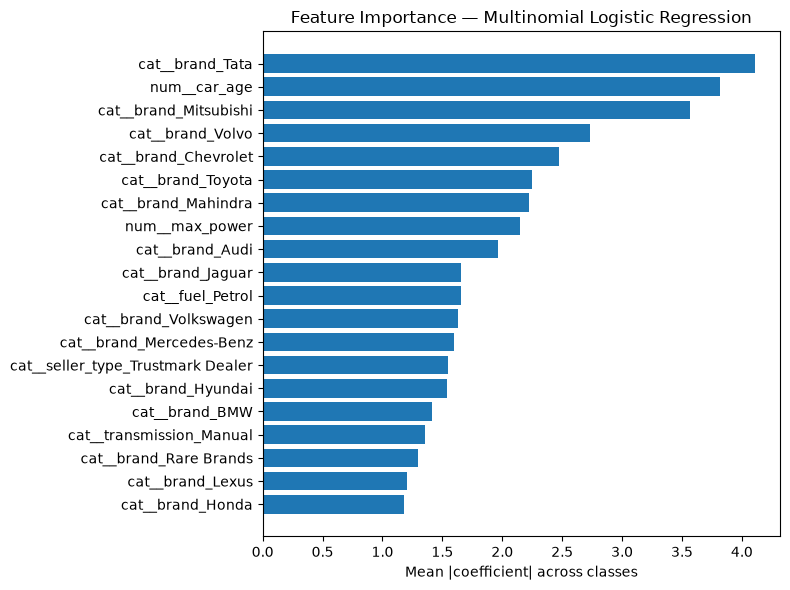

In [23]:

fig = final_model.plot_feature_importance(feature_names, top_n=20)
plt.show()



## 9. Deployment — Dash App, Docker, and CI/CD

The `app/` folder follows the same layout as A1/A2:

```
app/
├── Dockerfile
├── docker-compose.yaml
└── code/
    ├── app.py                       # Dash app: predicts a price class + range
    ├── model.py                     # the LogisticRegression class defined above
    ├── car_price_classifier_a3.pkl  # serialized artifact from Section 8
    ├── requirements.txt
    └── tests/
        └── test_model.py            # the two unit tests required by Task 3
```

New in A3 is `.github/workflows/ci-cd.yml`, which:

1. **test job** — on every push, installs dependencies and runs `pytest
   app/code/tests/`, which contains the two required unit tests: (1) the model
   accepts the expected preprocessed input, and (2) `predict`/`predict_proba`
   return the expected output shape.
2. **deploy job** — runs only `needs: test` (i.e. only if the tests pass),
   builds the Docker image and pushes it to Docker Hub. A commented-out SSH step
   is included for redeploying the container on `ml.brain.cs.ait.ac.th`; it
   needs `secrets.SSH_PRIVATE_KEY` / host details filled in before it can run.

See `README.md` in this folder for the full write-up (dataset, cleaning,
modelling, MLflow, deployment, and the CI/CD pipeline) and the exact steps
required on the CSIM server.



## 10. Discussion

**Class imbalance and metric choice.** Bucketing `selling_price` with equal-width
`pd.cut()` bins reproduces the same right-skew we saw in A1/A2's `selling_price`
histogram: the cheapest bucket dominates the dataset. This makes `macro avg` and
`weighted avg` diverge noticeably — `macro avg` treats the rare, expensive-car
classes as equally important as the common cheap-car class, while `weighted avg`
(and plain `accuracy`) are dominated by how well the model does on the majority
class. Neither is "more correct" in isolation; which one matters depends on
whether misclassifying a rare luxury car is as costly as misclassifying a common
budget car for the business.

**Ridge (L2).** A small `lambda_` gave a marginal improvement over the
unregularized model, consistent with A2's finding that Ridge does not hurt when
multicollinearity has already been addressed (`year` was dropped in favour of
`car_age`, exactly as in A1/A2) — it mainly guards against the one-hot encoded
`brand`/`fuel`/`seller_type`/`transmission` columns producing unstable
coefficients. Larger `lambda_` values under-fit and reduced every score.

**Feature importance.** `max_power`, `engine`, and several premium `brand`
categories carry the largest average coefficient magnitude across classes,
echoing A1/A2's finding that these same features were the strongest predictors
of the *continuous* selling price — reassuring, since the classification labels
here are just a bucketed version of that same target.

**Limitations.** The model is still linear (in the softmax sense) and the price
buckets are a somewhat arbitrary equal-width cut of a skewed variable — a
`pd.qcut()`-based cut would balance the classes but would also make the bucket
boundaries less interpretable to an end user. The MLflow registry/staging step
was demonstrated locally rather than against the real CSIM server; the
CI/CD deploy job's server-side redeploy step is left as a template because it
needs secrets and host access this environment doesn't have.
